<a href="https://colab.research.google.com/github/imnishu07/TensorFlow_Lite_Projects/blob/basicProjects/ArimaWithPredictionIntervals.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This notebook follows is an extension of the freecodecamp tutorial on time series forecasting. Main aim is to understand the basic time series models for ARIMA forecasting. It implements the Prediction interval features for different models.

In [21]:
#Import Dependencies

!pip install statsforecast utilsforecast

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from functools import partial # Import partial

from utilsforecast.plotting import plot_series
from utilsforecast.evaluation import evaluate # Updated import
from utilsforecast.losses import *
from statsforecast.models import AutoARIMA, SeasonalNaive # Import AutoARIMA and SeasonalNaive
from statsforecast import StatsForecast # Import StatsForecast

import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv('https://raw.githubusercontent.com/marcopeix/youtube_tutorials/refs/heads/main/data/daily_sales_french_bakery.csv', parse_dates=["ds"])

df = df.groupby('unique_id').filter(lambda x: len(x) >= 28)
df.head()

,unique_id,ds,y,unit_price
0,12 MACARON,2022-07-13,10.0,10.0
1,12 MACARON,2022-07-14,0.0,10.0
2,12 MACARON,2022-07-15,0.0,10.0
3,12 MACARON,2022-07-16,10.0,10.0
4,12 MACARON,2022-07-17,30.0,10.0


In [8]:
#Setup for Prediction intervals

unique_ids = ["BAGUETTE", "CROISSANT"]
small_df = df[df["unique_id"].isin(unique_ids)]
test = small_df.groupby("unique_id").tail(7)
train = small_df.drop(test.index).reset_index(drop=True)
train.head()

,unique_id,ds,y,unit_price
0,BAGUETTE,2021-01-02,41.4,0.9
1,BAGUETTE,2021-01-03,31.5,0.9
2,BAGUETTE,2021-01-04,27.0,0.9
3,BAGUETTE,2021-01-05,26.1,0.9
4,BAGUETTE,2021-01-06,0.0,0.9


In [11]:
models = [
    AutoARIMA(season_length=7)
]

# Define horizon
horizon = 7

sf = StatsForecast(models=models, freq="D")
sf.fit(df=train)
prob_preds = sf.predict(h=horizon, X_df=test.drop(columns=["y"], axis=1), level=[80])

In [12]:
test_df = test.merge(prob_preds, on=["unique_id", "ds"], how="left")

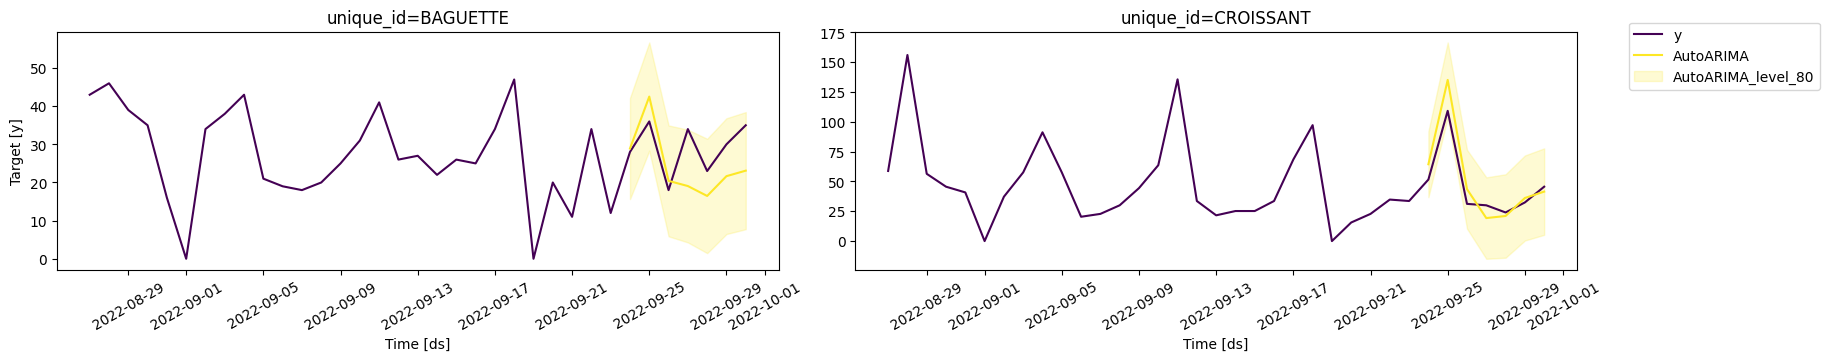

In [13]:
plot_series(
    df=train,
    forecasts_df=test_df,
    max_insample_length=28,
    models=["AutoARIMA"],
    level=[80],
    palette="viridis",
)

In [14]:
models = [
    AutoARIMA(season_length=7)
]

sf = StatsForecast(models=models, freq="D")

#Run cross-validation
cv_prob_df = sf.cross_validation(
    h=horizon,
    df=small_df,
    n_windows=8,
    step_size=horizon,
    refit=True,
    level=[80],
)

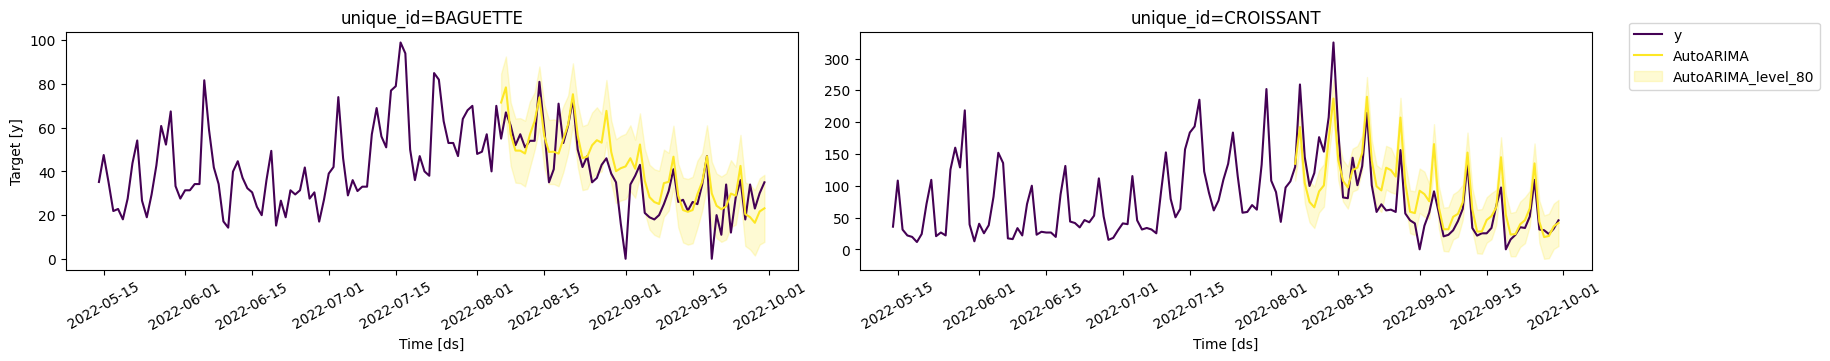

In [15]:
plot_series(
    df=small_df,
    forecasts_df=cv_prob_df.drop(["y", "cutoff"], axis=1),
    ids=["BAGUETTE", "CROISSANT"],
    max_insample_length=140,
    models=["AutoARIMA"],
    level=[80],
    palette="viridis",
)

In [19]:
#Evaluation metrics

models= [
    AutoARIMA(season_length=7, alias="SARIMA_exog"),
    SeasonalNaive(season_length=7)
]

sf = StatsForecast(models=models, freq="D")

#Run cross-validation
final_cv_df = sf.cross_validation(
    h=horizon,
    df=small_df,
    n_windows=8,
    step_size=horizon,
    refit=True,
    level=[80],
)

final_cv_df.head()

,unique_id,ds,cutoff,y,SARIMA_exog,SARIMA_exog-lo-80,SARIMA_exog-hi-80,SeasonalNaive,SeasonalNaive-lo-80,SeasonalNaive-hi-80
0,BAGUETTE,2022-08-06,2022-08-05,55.0,71.511528,58.279213,84.743843,68.0,50.158042,85.841958
1,BAGUETTE,2022-08-07,2022-08-05,67.0,78.458054,64.354114,92.561995,70.0,52.158042,87.841958
2,BAGUETTE,2022-08-08,2022-08-05,61.0,57.062745,42.622201,71.503290,48.0,30.158042,65.841958
3,BAGUETTE,2022-08-09,2022-08-05,52.0,49.525901,34.847356,64.204446,49.0,31.158042,66.841958
4,BAGUETTE,2022-08-10,2022-08-05,57.0,49.485683,34.606853,64.364512,57.0,39.158042,74.841958


In [22]:
temp_test = small_df.groupby("unique_id").tail(7*8)
temp_train = small_df.drop(test.index).reset_index(drop=True)

models = ["SARIMA_exog", "SeasonalNaive"]
metrics = [
    mae,
    mse,
    rmse,
    mape,
    smape,
    partial(mase, seasonality=7),
    scaled_crps
]

final_eval = evaluate(
    final_cv_df.drop(["ds", "cutoff"], axis=1),
    metrics=metrics,
    models=models,
    train_df=temp_train,
    level=[80],
)

final_eval = final_eval.drop(["unique_id"], axis=1).groupby('metric').mean().reset_index()
final_eval

,metric,SARIMA_exog,SeasonalNaive
0,mae,19.211687,21.117857
1,mape,0.328615,0.376819
2,mase,1.140788,1.285069
3,mse,792.788111,970.417143
4,rmse,24.979598,27.875413
5,scaled_crps,0.153636,0.166451
6,smape,0.168241,0.211317


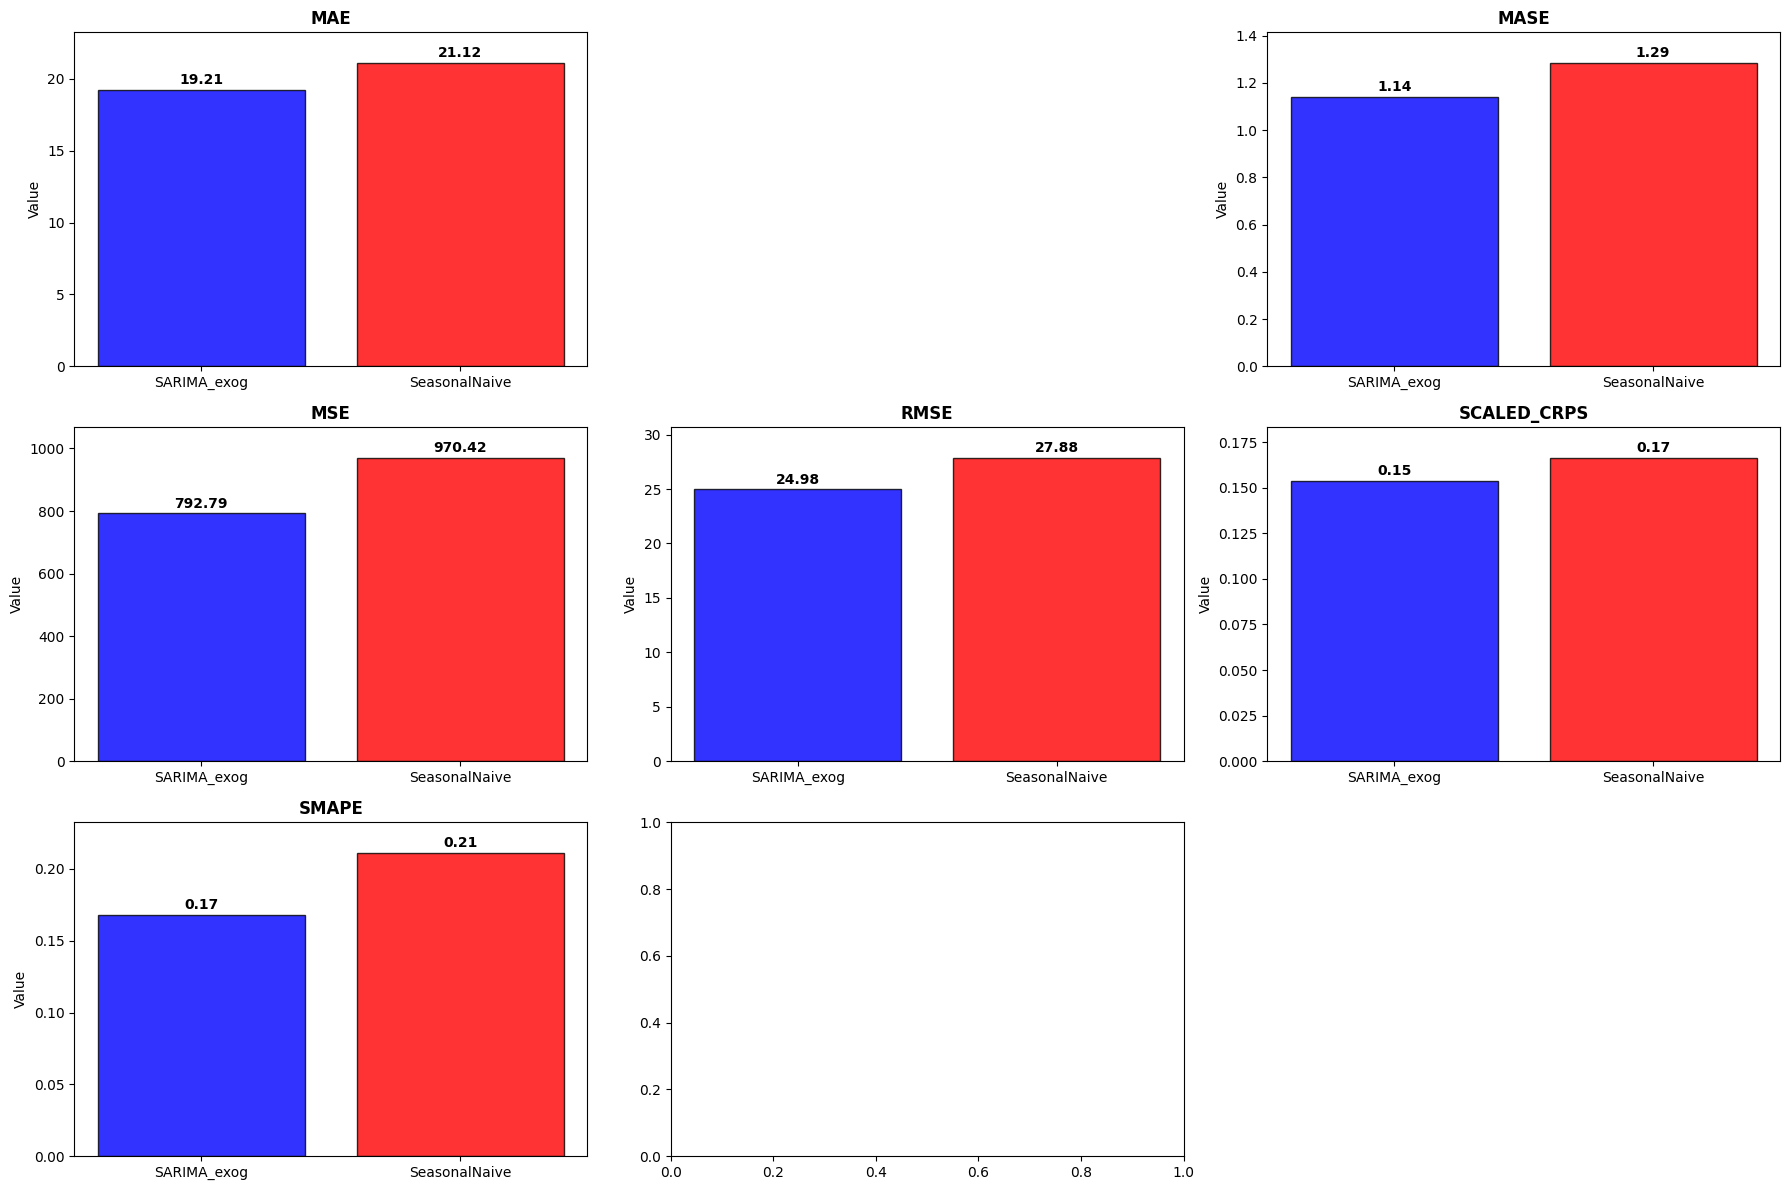

In [25]:
fig, axes = plt.subplots(3, 3, figsize=(18, 12))

axes_flat = axes.flatten()

models = ['SARIMA_exog', 'SeasonalNaive']
x_pos = [0,1]
colors= ['blue', 'red']

for i, row in final_eval.iterrows():
  ax = axes_flat[i]

  model_values = [row['SARIMA_exog'], row['SeasonalNaive']]

  bars = ax.bar(x_pos, model_values, color=colors, alpha=0.8, edgecolor='black', linewidth=1)

  for j, (bar,value) in enumerate(zip(bars, model_values)):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + height*0.01,
            f'{value:.2f}', ha='center', va='bottom', fontweight='bold', fontsize=10)

  ax.set_xticks(x_pos)
  ax.set_xticklabels(models, ha='center')
  ax.set_ylabel('Value')
  max_value = max(model_values)
  ax.set_ylim(0, max_value * 1.1)
  ax.set_title(row['metric'].upper(), fontweight='bold', fontsize=12)

fig.delaxes(axes_flat[1])

axes_flat[8].set_visible(False)
plt.tight_layout()
plt.show()